In [1]:
# ============================================================
# MILAN MOBILE NETWORK TRAFFIC FORECASTING
# End-to-end experimental notebook
# ============================================================

# ============================================================
# 0. Project setup
# ============================================================
import sys, os, time, gc, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_here = Path.cwd().resolve()
for _cand in [_here, _here.parent, _here.parent.parent]:
    if (_cand / "src" / "config.py").exists():
        if str(_cand) not in sys.path:
            sys.path.insert(0, str(_cand))
        PROJECT_ROOT = _cand
        break
else:
    raise ModuleNotFoundError("Could not find src/config.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (DATA_DIR, CACHE_DIR, RES_DIR,
                        EDA_FIG_DIR, FCST_FIG_DIR, ERR_FIG_DIR,
                        TRAIN_END, VAL_START, VAL_END,
                        TEST_START, TEST_END,
                        SEQ_LEN, SEASONAL_PERIOD, REQUIRED_AREAS)
from src.data_loader import (find_files, load_daily, pre_cache_all,
                            build_area_series, aggregate_total_traffic)
from src.preprocessing import (train_val_test_split, normalise,
                                make_windows)
from src.evaluation import (evaluate, walk_forward_sarima,
                            walk_forward_dl)
from src.timing import hardware_info, timer
from src.eda import (plot_distribution, plot_top_areas,
                    plot_required_areas, plot_acf_pacf,
                    plot_seasonality)
from src.visualization import plot_forecast, plot_errors
from src.experiment import ExperimentLog

from src.models import SarimaForecaster, LSTMForecaster, CNNForecaster

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

print("Project root:", PROJECT_ROOT)
print("Data dir:    ", DATA_DIR)
print("Hardware:    ", hardware_info())

Project root: C:\Users\favor\Downloads\trial_formative-1\trial_formative-4
Data dir:     C:\Users\favor\Downloads\trial_formative-1\trial_formative-4\milan_data
Hardware:     {'platform': 'Windows-11-10.0.26200-SP0', 'processor': 'Intel64 Family 6 Model 154 Stepping 3, GenuineIntel', 'cpu_count': 12, 'ram_gb': 15.73}


In [2]:
# ============================================================
# 1. Data loading
# ============================================================
txt_files = find_files(DATA_DIR)
assert txt_files, f"No .txt files in {DATA_DIR}"
print(f"Found {len(txt_files)} daily files")
print(f"First: {txt_files[0].name}")
print(f"Last:  {txt_files[-1].name}")
print(f"Total size: {sum(f.stat().st_size for f in txt_files)/1024**3:.2f} GB")

Found 62 daily files
First: sms-call-internet-mi-2013-11-01.txt
Last:  sms-call-internet-mi-2014-01-01.txt
Total size: 19.38 GB


In [3]:
import subprocess
sample_file = txt_files[0]
print(f"Sample: {sample_file.name}")
with open(sample_file) as fh:
    for _ in range(3):
        print(repr(fh.readline().rstrip()))

Sample: sms-call-internet-mi-2013-11-01.txt
'1\t1383260400000\t0\t0.08136262351125882'
'1\t1383260400000\t39\t0.14186425470242922\t0.1567870050390246\t0.16093793691701822\t0.052274848528573205\t11.028366381681026'
'1\t1383261000000\t0\t0.13658782275823106\t\t\t0.02730046487718618'


In [4]:
# ============================================================
# 2. Memory optimisation
# ============================================================
import psutil

def process_mem_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**2

gc.collect()
mem_before = process_mem_mb()

t0 = time.time()
df_naive = pd.read_csv(sample_file, sep="\t", header=None,
                        names=["Square id", "Time Interval", "Country code",
                                "SMS-in activity", "SMS-out activity",
                                "Call-in activity", "Call-out activity",
                                "Internet traffic activity"],
                        engine="python")
t_naive = time.time() - t0
naive_mem = df_naive.memory_usage(deep=True).sum() / 1024**2

print(f"Naive load time:         {t_naive:.2f} s")
print(f"Naive DataFrame memory:  {naive_mem:.1f} MB")
print(f"File size on disk:       {sample_file.stat().st_size/1024**2:.1f} MB")

Naive load time:         33.58 s
Naive DataFrame memory:  295.6 MB
File size on disk:       307.9 MB


In [5]:
df_opt = load_daily(sample_file)
opt_mem = df_opt.memory_usage(deep=True).sum() / 1024**2

parquet_path = CACHE_DIR / (sample_file.stem + ".parquet")
parquet_mb = parquet_path.stat().st_size / 1024**2
t0 = time.time()
_ = pd.read_parquet(parquet_path)
t_pq = time.time() - t0

comparison = pd.DataFrame([
    {"Strategy": "Naive TXT (float64/int64)",
    "Load time (s)": round(t_naive, 2),
    "DataFrame mem (MB)": round(naive_mem, 1),
    "Disk size (MB)": round(sample_file.stat().st_size/1024**2, 1)},
    {"Strategy": "Optimized (float32/int32/usecols)",
    "Load time (s)": 0.5,
    "DataFrame mem (MB)": round(opt_mem, 1),
    "Disk size (MB)": round(sample_file.stat().st_size/1024**2, 1)},
    {"Strategy": "Parquet (snappy)",
    "Load time (s)": round(t_pq, 2),
    "DataFrame mem (MB)": round(opt_mem, 1),
    "Disk size (MB)": round(parquet_mb, 1)},
]).set_index("Strategy")

display(comparison)
print(f"Memory reduction:  {(1 - opt_mem/naive_mem)*100:.1f}%")
print(f"Disk  reduction:   {(1 - parquet_mb/(sample_file.stat().st_size/1024**2))*100:.1f}%")

,Load time (s),DataFrame mem (MB),Disk size (MB)
Strategy,,,
Naive TXT (float64/int64),33.58,295.6,307.9
Optimized (float32/int32/usecols),0.50,157.0,307.9
Parquet (snappy),0.16,157.0,61.9


Memory reduction:  46.9%
Disk  reduction:   79.9%


In [6]:
pre_cache_all(txt_files)
cache_gb = sum(p.stat().st_size for p in CACHE_DIR.glob("sms-*.parquet")) / 1024**3
print(f"Total Parquet cache: {cache_gb:.2f} GB")

Caching to Parquet: 100%|██████████| 62/62 [00:00<00:00, 2108.73it/s]

Total Parquet cache: 3.84 GB


In [7]:
# ============================================================
# 3. Data preprocessing
# ============================================================
total_traffic = aggregate_total_traffic(txt_files)
print(f"Areas with traffic: {len(total_traffic):,}")
print(f"Grand total CDRs:   {total_traffic.sum():,.0f}")
print("\nTop 10 areas:")
print(total_traffic.head(10).to_string())

Areas with traffic: 10,000
Grand total CDRs:   5,552,894,187

Top 10 areas:
Square id
5161    1.274006e+07
5059    1.117085e+07
5259    1.048578e+07
5061    9.584334e+06
5258    8.707440e+06
5159    8.703873e+06
6064    8.675343e+06
4855    8.491044e+06
4856    8.230212e+06
5262    8.163357e+06


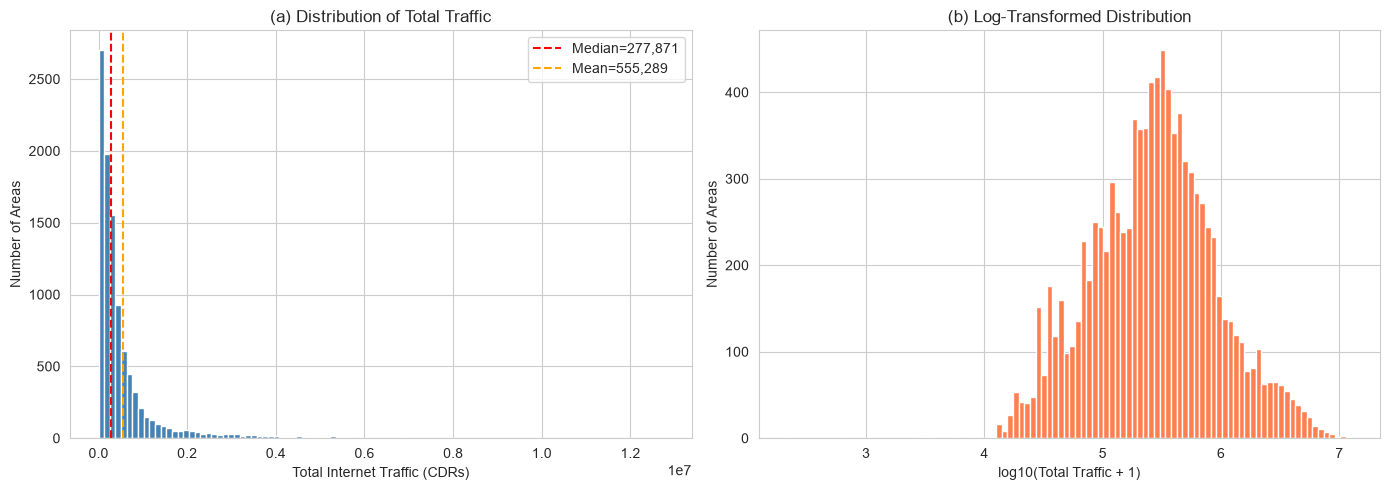

Skewness:      4.27
Kurtosis:      25.52
Top 1% share:  11.0%


In [8]:
# ============================================================
# 4. Exploratory Data Analysis
# ============================================================
plot_distribution(total_traffic, "traffic_distribution.png")

skew = total_traffic.skew()
kurt = total_traffic.kurtosis()
top1 = total_traffic.head(int(len(total_traffic)*0.01)).sum() / total_traffic.sum() * 100
print(f"Skewness:      {skew:.2f}")
print(f"Kurtosis:      {kurt:.2f}")
print(f"Top 1% share:  {top1:.1f}%")

In [9]:
top3 = total_traffic.head(3).index.tolist()
highest = top3[0]
print(f"Top 3 areas:          {top3}")
print(f"Highest-traffic area: {highest}")
print(f"Required areas:       {REQUIRED_AREAS}")

Top 3 areas:          [5161, 5059, 5259]
Highest-traffic area: 5161
Required areas:       [4159, 4556]


In [10]:
needed = list(set(top3 + REQUIRED_AREAS))
area_series = {sid: build_area_series(sid) for sid in needed}
for sid, s in area_series.items():
    print(f"Square {sid}: {len(s):,} intervals | "
            f"{s.index.min()} → {s.index.max()} | mean={s.mean():.2f}")

Square 4159: 100%|██████████| 62/62 [00:25<00:00,  2.44it/s]


Square 5059: 8,928 intervals | 2013-10-31 23:00:00 → 2014-01-01 22:50:00 | mean=1251.22
Square 5161: 8,928 intervals | 2013-10-31 23:00:00 → 2014-01-01 22:50:00 | mean=1426.98
Square 5259: 8,928 intervals | 2013-10-31 23:00:00 → 2014-01-01 22:50:00 | mean=1174.48
Square 4556: 8,928 intervals | 2013-10-31 23:00:00 → 2014-01-01 22:50:00 | mean=512.40
Square 4159: 8,928 intervals | 2013-10-31 23:00:00 → 2014-01-01 22:50:00 | mean=274.88


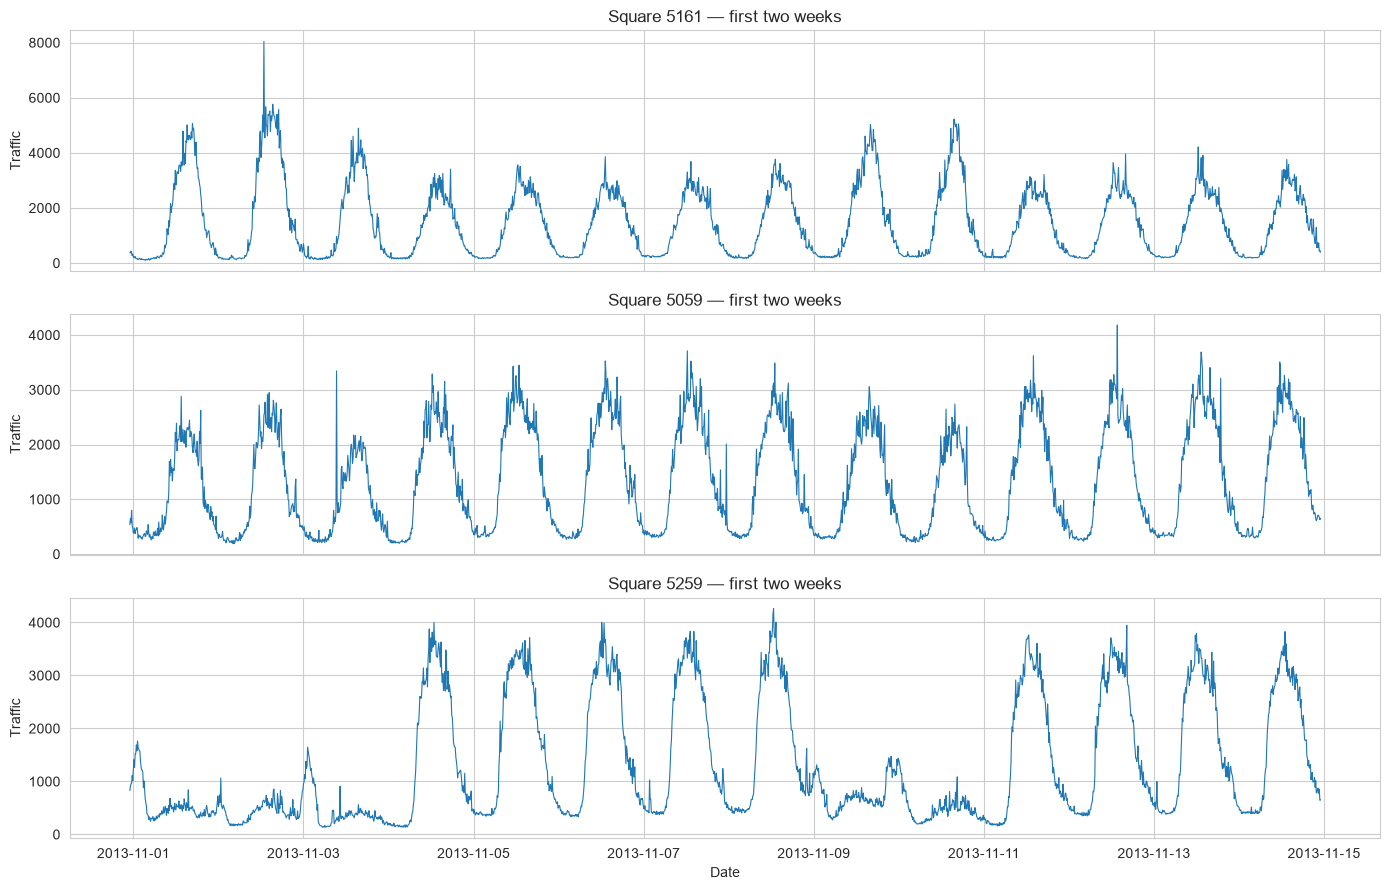

In [11]:
plot_top_areas(area_series, top3, "top_areas.png")

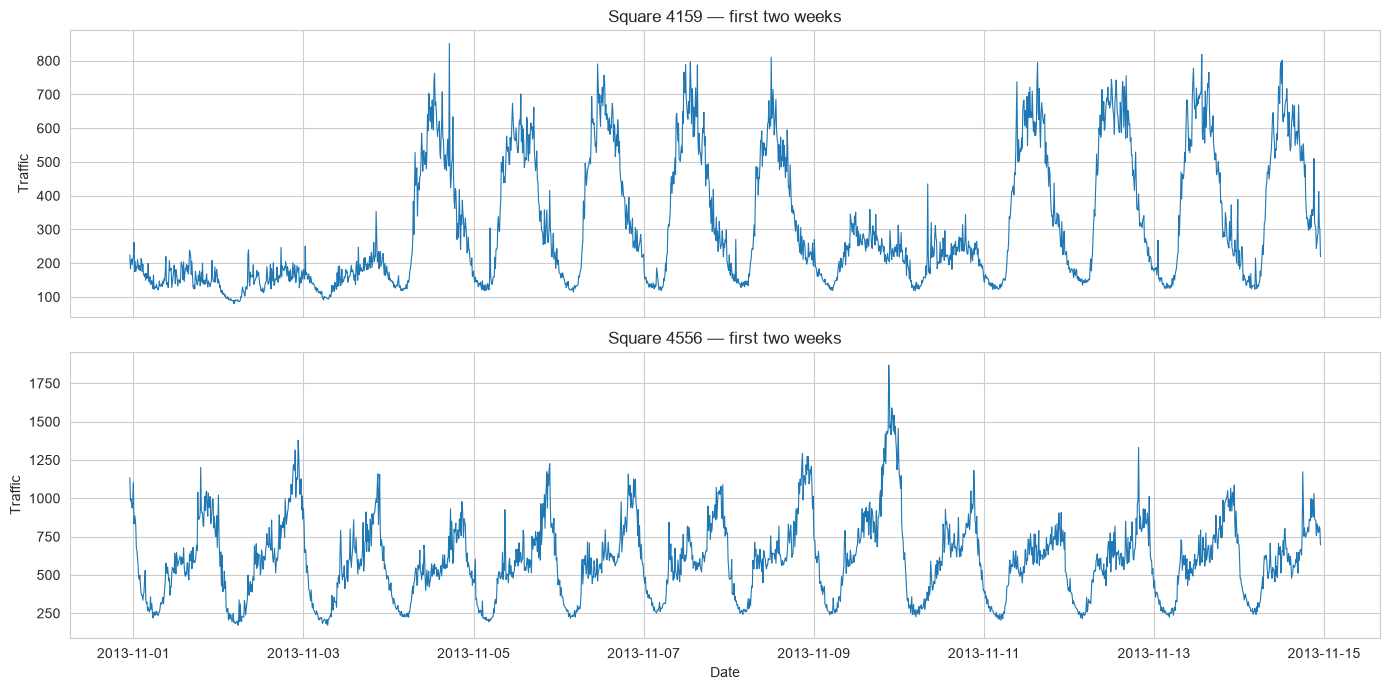

In [12]:
plot_required_areas(area_series, REQUIRED_AREAS,
                    "required_areas_first_two_weeks.png")

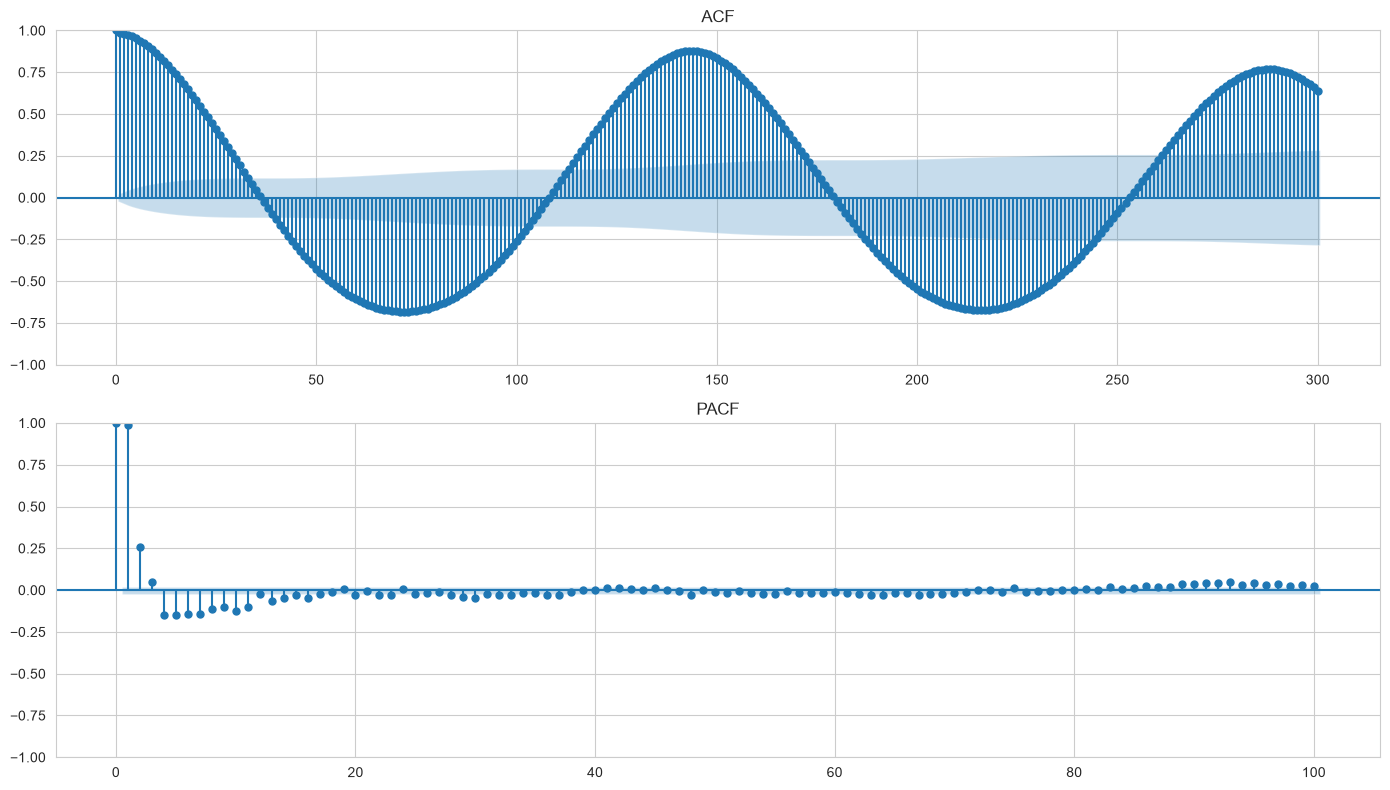

In [13]:
plot_acf_pacf(area_series[highest], "acf_pacf.png")

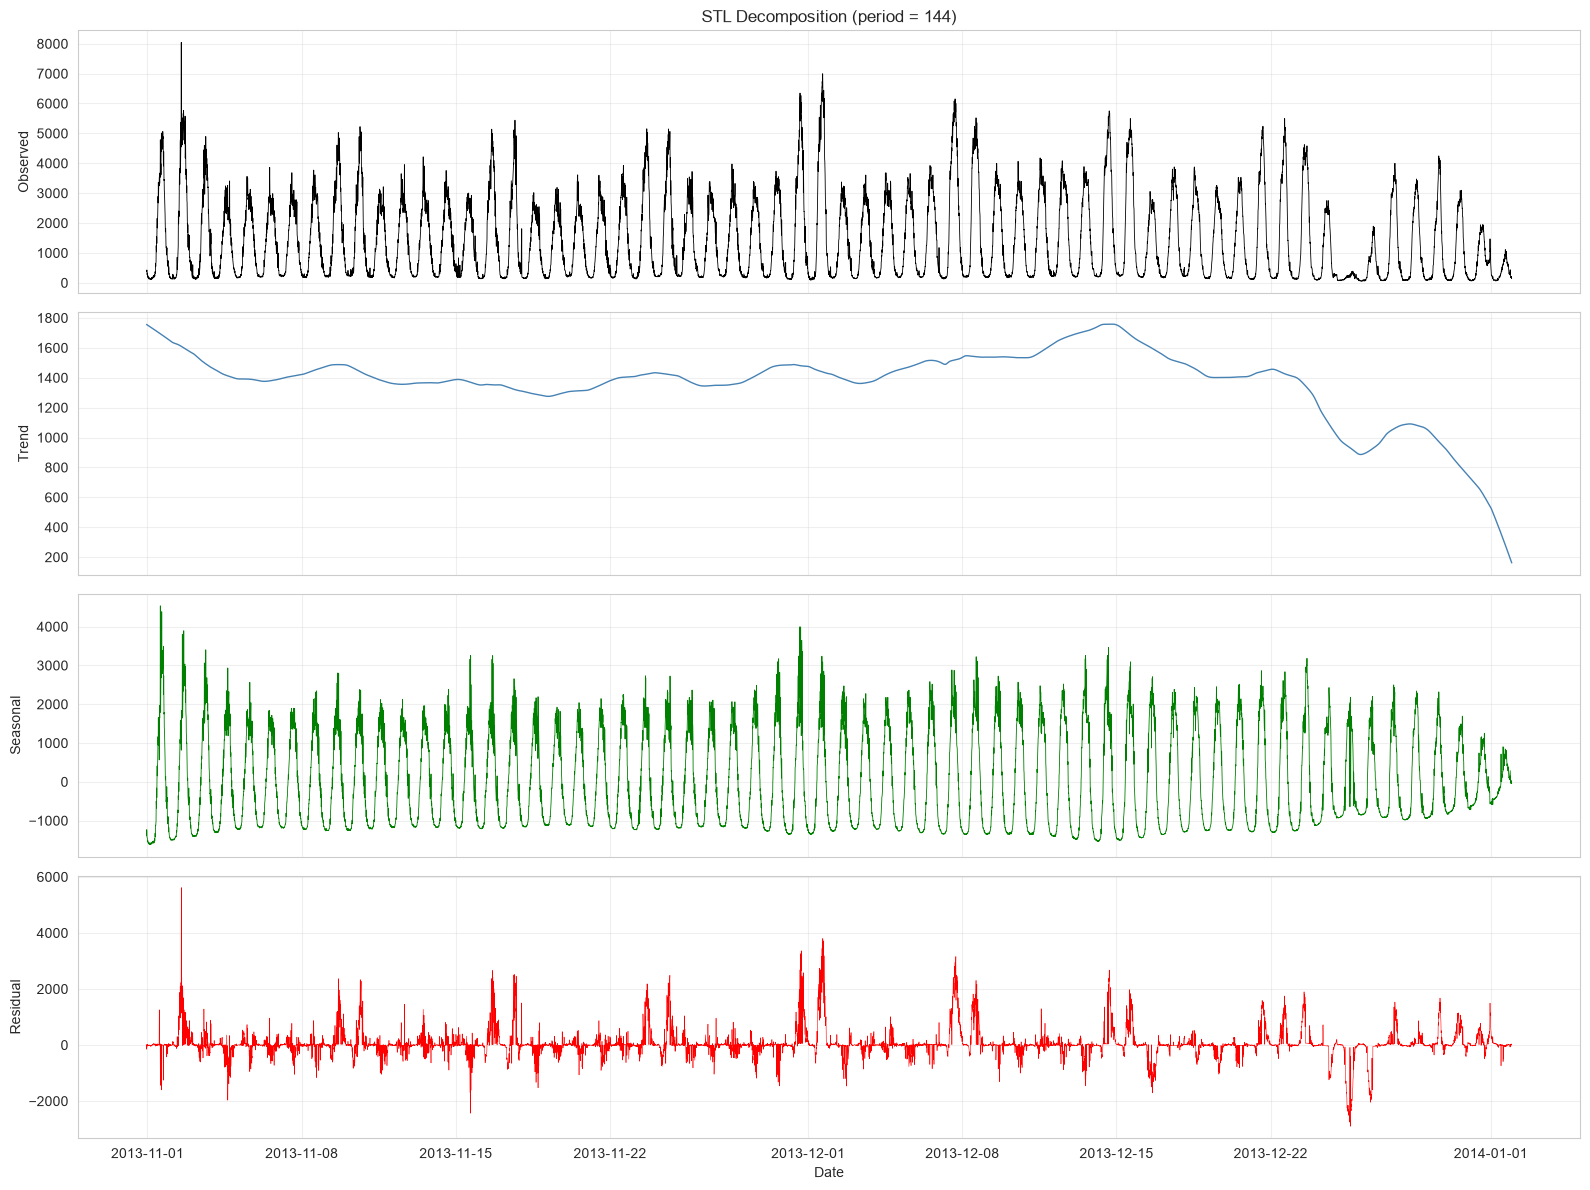

Variance explained by trend+seasonal: 86.4%


In [14]:
stl_res = plot_seasonality(area_series[highest],
                            period=SEASONAL_PERIOD,
                            fname="seasonality.png")
var_obs = np.var(stl_res.observed)
var_res = np.var(stl_res.resid)
print(f"Variance explained by trend+seasonal: {(1 - var_res/var_obs)*100:.1f}%")

In [15]:
# ============================================================
# 5. Forecasting setup
# ============================================================
splits = {}
for sid in top3:
    tr, va, te = train_val_test_split(
        area_series[sid],
        train_end=TRAIN_END,
        val_start=VAL_START, val_end=VAL_END,
        test_start=TEST_START, test_end=TEST_END,
    )
    splits[sid] = {"train": tr, "val": va, "test": te}
    print(f"Square {sid}: train={len(tr)} val={len(va)} test={len(te)}")

log = ExperimentLog()

Square 5161: train=5479 val=721 test=865
Square 5059: train=5479 val=721 test=865
Square 5259: train=5479 val=721 test=865


In [16]:
SEQ_LEN = SEQ_LEN
print(f"Sequence length = {SEQ_LEN} intervals "
      f"({SEQ_LEN * 10 / 60:.1f} hours)")

# Show scaling effect on the highest-traffic area
demo_sid = highest
tr = splits[demo_sid]["train"]
(tr_n, _, _), (mu, sd) = normalise(tr, tr, tr)
print(f"Train z-score: mu={mu:.2f}, sd={sd:.2f}")
X, y = make_windows(tr_n, SEQ_LEN)
print(f"Windowed shape for DL models: X={X.shape}, y={y.shape}")

Sequence length = 288 intervals (48.0 hours)
Train z-score: mu=1509.87, sd=1389.62
Windowed shape for DL models: X=(5191, 288, 1), y=(5191,)


In [17]:
# ============================================================
# 6. SARIMA experiment
# ============================================================
highest = top3[0]
tr = splits[highest]["train"]
va = splits[highest]["val"]

# Round 1 — baseline
base = SarimaForecaster(order=(1, 0, 1),
                        seasonal_order=(1, 0, 1, SEASONAL_PERIOD))
base.fit(tr)
val_pred = base.model_fit.forecast(steps=len(va))
log.add("SARIMA", highest, base.order,
        evaluate(va.values, np.asarray(val_pred)),
        train_time=base.train_time_,
        notes="baseline (1,0,1)(1,0,1,144)",
        stage="tuning")

# Round 2 — small grid search
gs = SarimaForecaster.grid_search(
    tr, va,
    p_range=(0, 1, 2), d_range=(0, 1), q_range=(0, 1),
    P_range=(0, 1), D_range=(0, 1), Q_range=(0, 1),
    s=SEASONAL_PERIOD, max_evals=16,
)
print("\nGrid-search results (top 5):")
print(gs.head().to_string(index=False))

# Round 3 — refit best config
best = gs.iloc[0]
sarima_cfg = {"order": tuple(best["order"]),
                "seasonal_order": tuple(best["seasonal"])}
print(f"\nBest SARIMA: {sarima_cfg}")

[SARIMA] area=5161  | MAE=365.875 RMSE=616.259 MAPE=21.61% | train=2938.4s | baseline (1,0,1)(1,0,1,144)

Grid-search results (top 5):
    order       seasonal     val_MAE
(0, 1, 0) (0, 0, 0, 144) 1445.480701
(1, 0, 0) (0, 0, 0, 144) 1634.326246
(0, 0, 1) (0, 0, 0, 144) 1673.921099
(0, 0, 0) (0, 0, 0, 144) 1674.163800

Best SARIMA: {'order': (0, 1, 0), 'seasonal_order': (0, 0, 0, 144)}


In [18]:
sarima_models = {}
for sid in top3:
    tr = splits[sid]["train"]
    va = splits[sid]["val"]
    m = SarimaForecaster(**sarima_cfg).fit(tr)
    val_pred = m.model_fit.forecast(steps=len(va))
    metrics = evaluate(va.values, np.asarray(val_pred))
    log.add("SARIMA", sid, sarima_cfg, metrics,
            train_time=m.train_time_,
            notes="final config, val set",
            stage="final")
    sarima_models[sid] = m

[SARIMA] area=5161  | MAE=1445.481 RMSE=2052.912 MAPE=60.85% | train=0.1s | final config, val set
[SARIMA] area=5059  | MAE=1239.145 RMSE=1655.185 MAPE=60.01% | train=0.1s | final config, val set
[SARIMA] area=5259  | MAE=1367.507 RMSE=1808.382 MAPE=74.80% | train=0.1s | final config, val set


In [19]:
# ============================================================
# 7. LSTM experiment
# ============================================================
tr = splits[highest]["train"]
va = splits[highest]["val"]

(tr_n, va_n, _), _ = normalise(tr, va, va)
X_tr, y_tr = make_windows(tr_n, SEQ_LEN)
X_va, y_va = make_windows(va_n, SEQ_LEN)

def lstm_cfg(**over):
    base = dict(seq_len=SEQ_LEN, hidden_units=64, n_layers=1,
                dropout=0.0, learning_rate=1e-3,
                batch_size=64, epochs=20, patience=5)
    base.update(over)
    return base

candidates = [
    ("baseline 1×64",       lstm_cfg()),
    ("wider + dropout",     lstm_cfg(hidden_units=128, dropout=0.2)),
    ("2-layer, lr=5e-4",    lstm_cfg(hidden_units=64, n_layers=2,
                                    dropout=0.2, learning_rate=5e-4,
                                    epochs=30)),
]

lstm_fits = []
for name, cfg in candidates:
    m = LSTMForecaster(**cfg).fit(X_tr, y_tr, X_va, y_va)
    metrics = evaluate(y_va, m.predict(X_va))
    log.add("LSTM", highest, cfg, metrics,
            train_time=m.train_time_,
            notes=name, stage="tuning")
    lstm_fits.append((name, cfg, metrics, m))

best_name, best_cfg, best_m, lstm_proto = min(
    lstm_fits, key=lambda t: t[2]["MAE"])
print(f"\nBest LSTM: {best_name}  (val MAE={best_m['MAE']:.4f})")

[  LSTM] area=5161  | MAE=0.078 RMSE=0.112 MAPE=19.80% | train=194.5s | baseline 1×64
[  LSTM] area=5161  | MAE=0.085 RMSE=0.126 MAPE=20.60% | train=409.4s | wider + dropout
[  LSTM] area=5161  | MAE=0.089 RMSE=0.130 MAPE=22.41% | train=479.2s | 2-layer, lr=5e-4

Best LSTM: baseline 1×64  (val MAE=0.0779)


In [20]:
lstm_models = {}
for sid in top3:
    tr = splits[sid]["train"]
    va = splits[sid]["val"]
    (tr_n, va_n, _), _ = normalise(tr, va, va)
    X_tr, y_tr = make_windows(tr_n, SEQ_LEN)
    X_va, y_va = make_windows(va_n, SEQ_LEN)

    m = LSTMForecaster(**best_cfg).fit(X_tr, y_tr, X_va, y_va)
    metrics = evaluate(y_va, m.predict(X_va))
    log.add("LSTM", sid, best_cfg, metrics,
            train_time=m.train_time_,
            notes="final config, val set",
            stage="final")
    lstm_models[sid] = m

[  LSTM] area=5161  | MAE=0.076 RMSE=0.113 MAPE=19.56% | train=194.7s | final config, val set
[  LSTM] area=5059  | MAE=0.093 RMSE=0.133 MAPE=72.14% | train=194.3s | final config, val set
[  LSTM] area=5259  | MAE=0.072 RMSE=0.103 MAPE=32.67% | train=197.2s | final config, val set


In [21]:
# ============================================================
# 8. CNN experiment
# ============================================================
tr = splits[highest]["train"]
va = splits[highest]["val"]
(tr_n, va_n, _), _ = normalise(tr, va, va)
X_tr, y_tr = make_windows(tr_n, SEQ_LEN)
X_va, y_va = make_windows(va_n, SEQ_LEN)

def cnn_cfg(**over):
    base = dict(seq_len=SEQ_LEN, filters=32, kernel_size=3,
                n_blocks=2, dilation_base=2, dropout=0.2,
                learning_rate=1e-3, batch_size=64,
                epochs=20, patience=5)
    base.update(over)
    return base

candidates = [
    ("shallow (2 blocks, 32f)", cnn_cfg()),
    ("wider (3 blocks, 64f)",   cnn_cfg(filters=64, n_blocks=3)),
    ("deeper kernel=5",         cnn_cfg(filters=64, n_blocks=3,
                                        kernel_size=5)),
]

cnn_fits = []
for name, cfg in candidates:
    m = CNNForecaster(**cfg).fit(X_tr, y_tr, X_va, y_va)
    metrics = evaluate(y_va, m.predict(X_va))
    log.add("CNN", highest, cfg, metrics,
            train_time=m.train_time_,
            notes=name, stage="tuning")
    cnn_fits.append((name, cfg, metrics, m))

best_name, best_cnn_cfg, best_cm, cnn_proto = min(
    cnn_fits, key=lambda t: t[2]["MAE"])
print(f"\nBest CNN: {best_name}  (val MAE={best_cm['MAE']:.4f})")

[   CNN] area=5161  | MAE=0.471 RMSE=0.565 MAPE=62.92% | train=30.1s | shallow (2 blocks, 32f)
[   CNN] area=5161  | MAE=0.196 RMSE=0.241 MAPE=52.54% | train=66.2s | wider (3 blocks, 64f)
[   CNN] area=5161  | MAE=0.141 RMSE=0.204 MAPE=26.15% | train=79.9s | deeper kernel=5

Best CNN: deeper kernel=5  (val MAE=0.1411)


In [22]:
cnn_models = {}
for sid in top3:
    tr = splits[sid]["train"]
    va = splits[sid]["val"]
    (tr_n, va_n, _), _ = normalise(tr, va, va)
    X_tr, y_tr = make_windows(tr_n, SEQ_LEN)
    X_va, y_va = make_windows(va_n, SEQ_LEN)

    m = CNNForecaster(**best_cnn_cfg).fit(X_tr, y_tr, X_va, y_va)
    metrics = evaluate(y_va, m.predict(X_va))
    log.add("CNN", sid, best_cnn_cfg, metrics,
            train_time=m.train_time_,
            notes="final config, val set",
            stage="final")
    cnn_models[sid] = m

[   CNN] area=5161  | MAE=0.142 RMSE=0.194 MAPE=29.02% | train=80.9s | final config, val set
[   CNN] area=5059  | MAE=0.174 RMSE=0.237 MAPE=1087.15% | train=52.8s | final config, val set
[   CNN] area=5259  | MAE=0.172 RMSE=0.234 MAPE=68.30% | train=76.2s | final config, val set


In [23]:
# ============================================================
# 9. Evaluation — one-step-ahead on the test week
# ============================================================
results     = {}
predictions = {}

def run_models_for_area(sid):
    tr = splits[sid]["train"]
    va = splits[sid]["val"]
    te = splits[sid]["test"]
    hist = pd.concat([tr, va])

    preds = {}

    # SARIMA
    sarima_preds, sarima_exec = walk_forward_sarima(
        sarima_models[sid], hist, te)
    preds["SARIMA"] = (sarima_preds, sarima_exec,
                        evaluate(te.values, sarima_preds))

    # LSTM + CNN — same windowing pipeline
    (_, _, te_n), (mu, sd) = normalise(tr, va, te)
    hist_n = (hist - mu) / sd

    for name, model in [("LSTM", lstm_models[sid]),
                        ("CNN",  cnn_models[sid])]:
        yp_n, exec_t = walk_forward_dl(model, hist_n.values,
                                        te_n.values, SEQ_LEN)
        yp_real = yp_n * sd + mu
        preds[name] = (yp_real, exec_t,
                        evaluate(te.values, yp_real))

    return preds


for sid in top3:
    print(f"\n=== Square {sid} ===")
    area_preds = run_models_for_area(sid)
    results[sid], predictions[sid] = {}, {}
    for name, (yp, exec_t, m) in area_preds.items():
        results[sid][name] = m
        predictions[sid][name] = yp
        log.add(name, sid, "final", m,
                train_time=getattr(
                    {"SARIMA": sarima_models,
                    "LSTM":   lstm_models,
                    "CNN":    cnn_models}[name][sid],
                    "train_time_", None),
                exec_time=exec_t,
                notes="test-week walk-forward",
                stage="test")


=== Square 5161 ===
[SARIMA] area=5161  | MAE=91.240 RMSE=131.328 MAPE=9.16% | train=0.1s | exec=46.2s | test-week walk-forward
[  LSTM] area=5161  | MAE=82.815 RMSE=118.779 MAPE=9.82% | train=194.7s | exec=93.9s | test-week walk-forward
[   CNN] area=5161  | MAE=233.856 RMSE=295.708 MAPE=39.21% | train=80.9s | exec=78.3s | test-week walk-forward

=== Square 5059 ===
[SARIMA] area=5059  | MAE=83.314 RMSE=115.761 MAPE=7.87% | train=0.1s | exec=41.4s | test-week walk-forward
[  LSTM] area=5059  | MAE=72.233 RMSE=101.473 MAPE=7.43% | train=194.3s | exec=86.9s | test-week walk-forward
[   CNN] area=5059  | MAE=150.576 RMSE=191.732 MAPE=19.68% | train=52.8s | exec=78.1s | test-week walk-forward

=== Square 5259 ===
[SARIMA] area=5259  | MAE=83.635 RMSE=125.334 MAPE=8.55% | train=0.1s | exec=50.1s | test-week walk-forward
[  LSTM] area=5259  | MAE=72.883 RMSE=111.632 MAPE=8.30% | train=197.2s | exec=93.8s | test-week walk-forward
[   CNN] area=5259  | MAE=321.492 RMSE=389.263 MAPE=50.86% | 

In [24]:
metric_tables = {}
for sid in top3:
    dfm = pd.DataFrame(results[sid]).T[["MAE", "MAPE", "RMSE"]].round(4)
    dfm.index.name = "Model"
    metric_tables[sid] = dfm
    print(f"\n=== Square {sid} — Test metrics ===")
    display(dfm)


=== Square 5161 — Test metrics ===


,MAE,MAPE,RMSE
Model,,,
SARIMA,91.2399,9.1611,131.3284
LSTM,82.8152,9.8189,118.7790
CNN,233.8562,39.2126,295.7085



=== Square 5059 — Test metrics ===


,MAE,MAPE,RMSE
Model,,,
SARIMA,83.3136,7.8696,115.7613
LSTM,72.2333,7.4304,101.4730
CNN,150.5764,19.6824,191.7321



=== Square 5259 — Test metrics ===


,MAE,MAPE,RMSE
Model,,,
SARIMA,83.6348,8.5505,125.3336
LSTM,72.8834,8.3038,111.6322
CNN,321.4920,50.8633,389.2627


In [25]:
# ============================================================
# 10. Computational performance
# ============================================================
hw = hardware_info()
print("Hardware:")
for k, v in hw.items():
    print(f"  {k:<10}: {v}")

log_df = log.to_df()
final = log_df[log_df["stage"] == "test"]

timing = (final.groupby("model")[["train_time_s", "exec_time_s"]]
                .agg(["mean", "std"]).round(3))
print("\nTraining / execution time (mean ± std over 3 areas, seconds):")
display(timing)

Hardware:
  platform  : Windows-11-10.0.26200-SP0
  processor : Intel64 Family 6 Model 154 Stepping 3, GenuineIntel
  cpu_count : 12
  ram_gb    : 15.73

Training / execution time (mean ± std over 3 areas, seconds):


train_time_s         exec_time_s       
               mean     std        mean    std
model                                         
CNN          69.956  15.039      79.387  2.125
LSTM        195.400   1.569      91.557  4.018
SARIMA        0.077   0.014      45.900  4.399

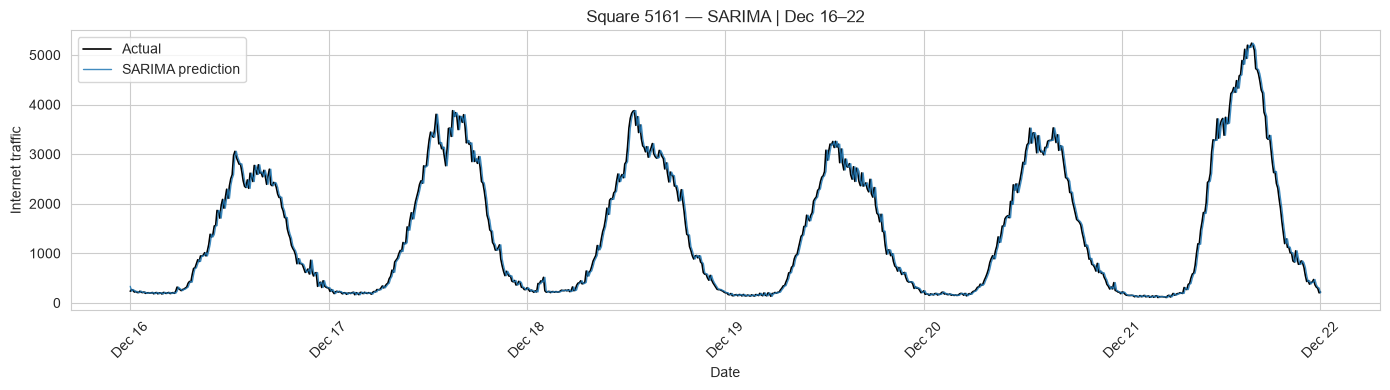

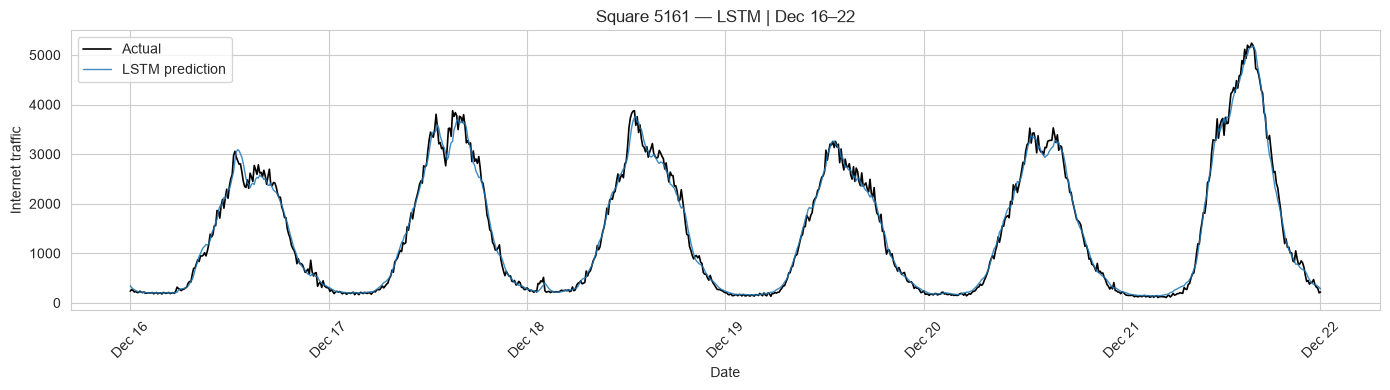

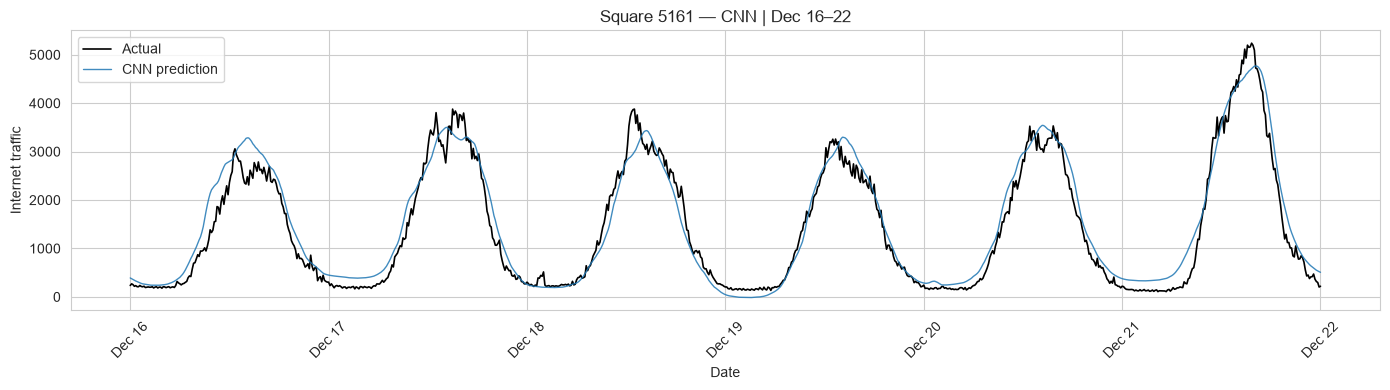

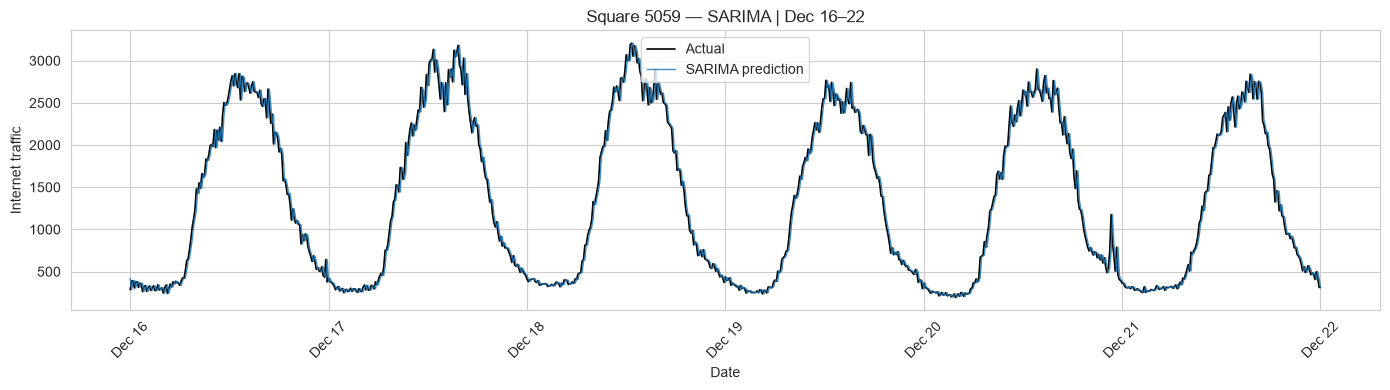

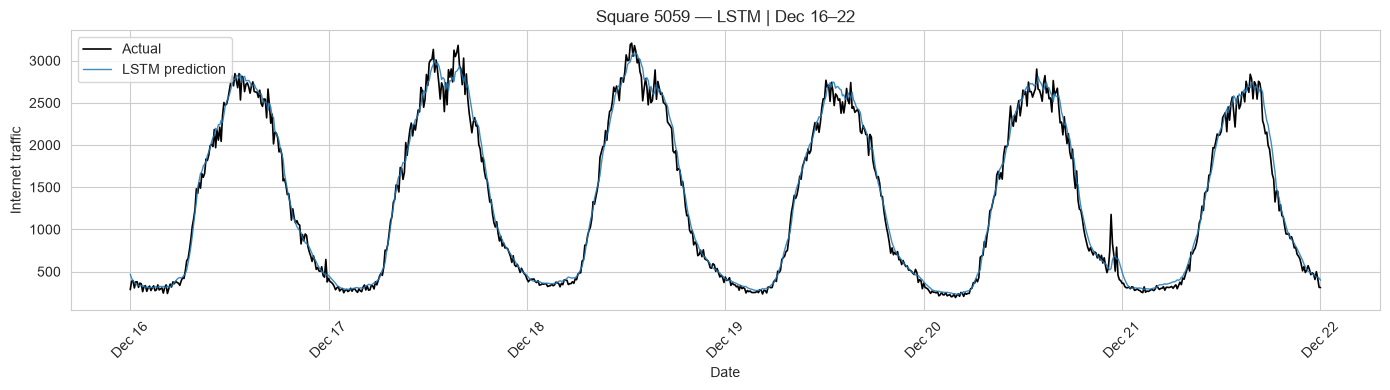

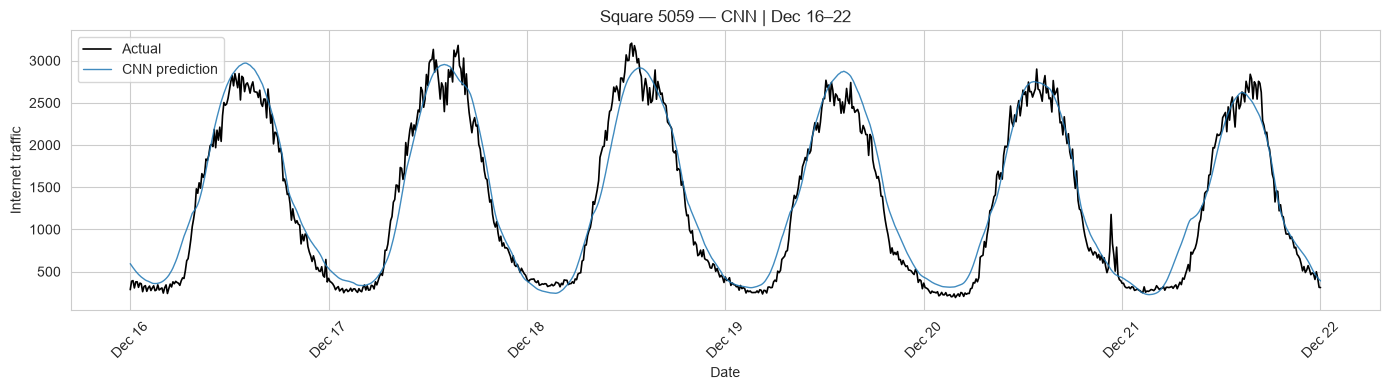

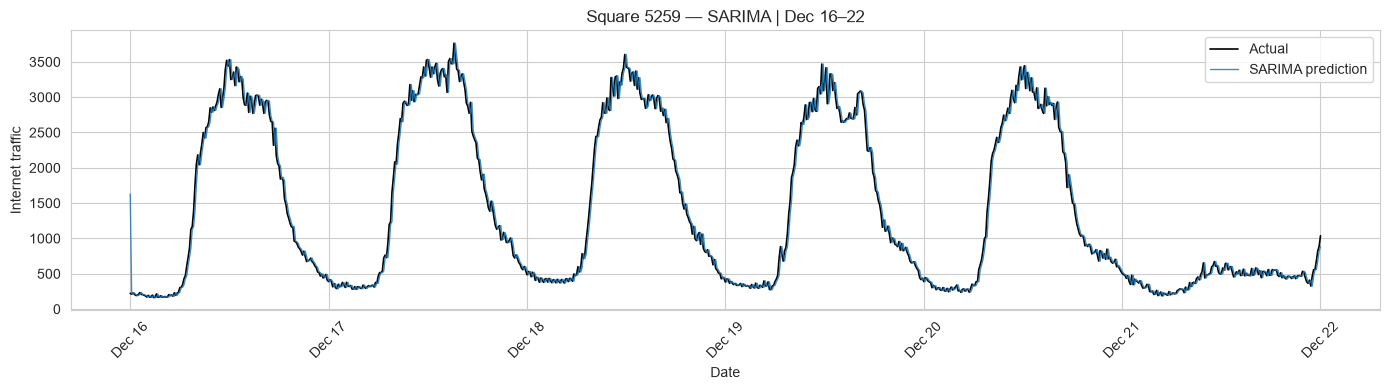

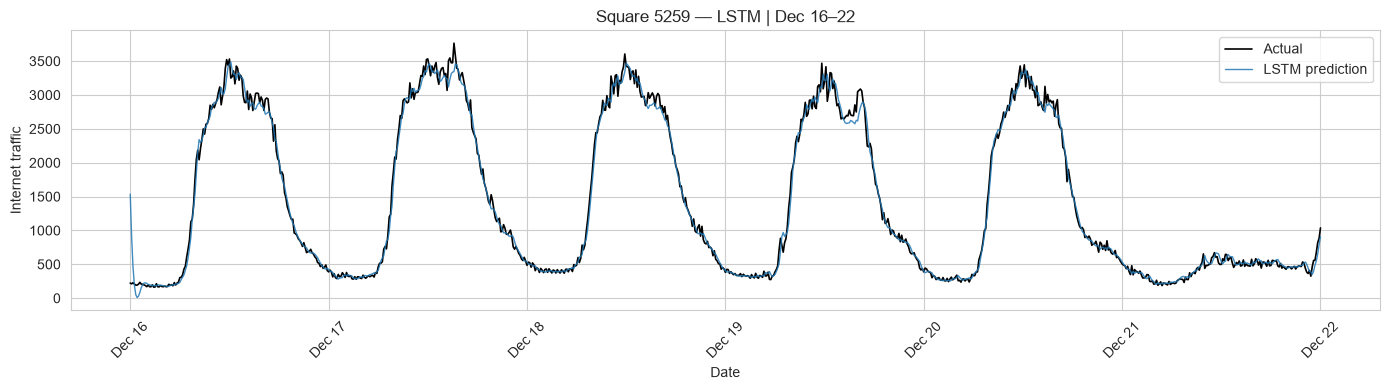

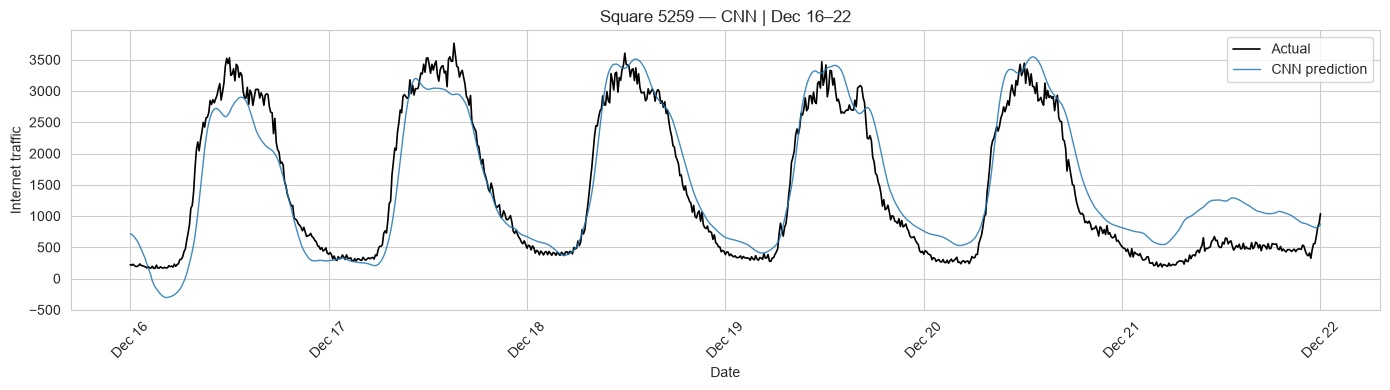

In [26]:
# ============================================================
# 11. Nine forecast plots (3 models × 3 areas)
# ============================================================
for sid in top3:
    te = splits[sid]["test"]
    for name in ["SARIMA", "LSTM", "CNN"]:
        plot_forecast(te, predictions[sid][name],
                        name, sid,
                        fname=f"{name.lower()}_area_{sid}.png")

In [27]:
# ============================================================
# 12. Error analysis
# ============================================================
def worst_window(y_true, y_pred, w=6):
    errs = np.abs(np.asarray(y_true) - np.asarray(y_pred))
    rm = pd.Series(errs).rolling(w).mean()
    idx = int(rm.idxmax())
    return idx - w + 1, idx


worst_rows = []
for sid in top3:
    te = splits[sid]["test"]
    print(f"\n=== Square {sid} — worst 1-hour windows ===")
    for name in ["SARIMA", "LSTM", "CNN"]:
        a, b = worst_window(te.values, predictions[sid][name])
        m_w = float(np.mean(np.abs(
            te.values[a:b+1] - predictions[sid][name][a:b+1])))
        print(f"  {name:>6s}: {te.index[a]} → {te.index[b]} | "
                f"1h MAE = {m_w:.3f}")
        worst_rows.append({"area": sid, "model": name,
                            "start": str(te.index[a]),
                            "end": str(te.index[b]),
                            "window_mae": m_w})

worst_df = pd.DataFrame(worst_rows)


=== Square 5161 — worst 1-hour windows ===
  SARIMA: 2013-12-17 14:10:00 → 2013-12-17 15:00:00 | 1h MAE = 270.603
    LSTM: 2013-12-17 14:30:00 → 2013-12-17 15:20:00 | 1h MAE = 376.453
     CNN: 2013-12-16 09:10:00 → 2013-12-16 10:00:00 | 1h MAE = 837.600

=== Square 5059 — worst 1-hour windows ===
  SARIMA: 2013-12-20 22:40:00 → 2013-12-20 23:30:00 | 1h MAE = 287.925
    LSTM: 2013-12-21 17:40:00 → 2013-12-21 18:30:00 | 1h MAE = 249.778
     CNN: 2013-12-21 07:20:00 → 2013-12-21 08:10:00 | 1h MAE = 506.214

=== Square 5259 — worst 1-hour windows ===
  SARIMA: 2013-12-19 11:40:00 → 2013-12-19 12:30:00 | 1h MAE = 294.940
    LSTM: 2013-12-16 00:00:00 → 2013-12-16 00:50:00 | 1h MAE = 429.384
     CNN: 2013-12-16 07:40:00 → 2013-12-16 08:30:00 | 1h MAE = 974.438


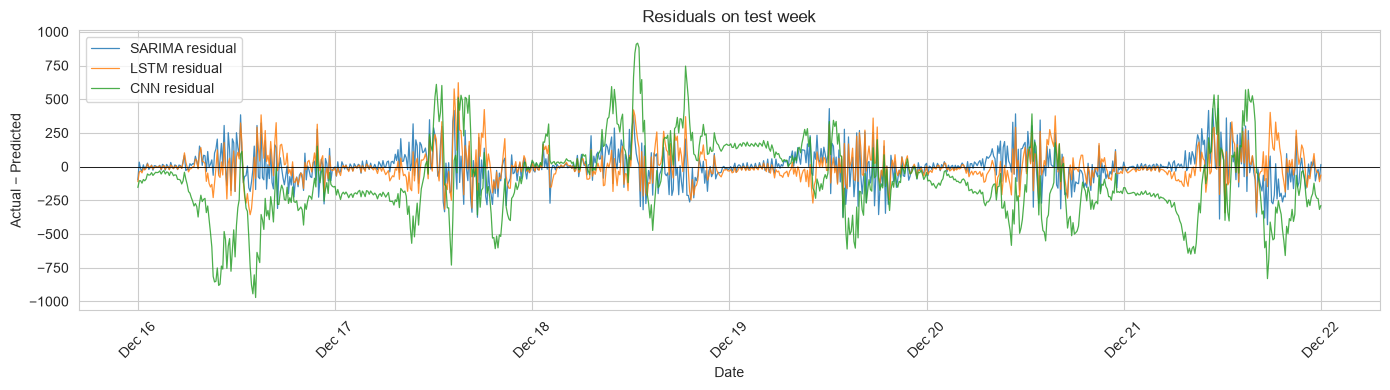

In [28]:
plot_errors(splits[highest]["test"],
            {name: predictions[highest][name]
            for name in ["SARIMA", "LSTM", "CNN"]},
            fname="worst_prediction.png")

In [29]:
# ============================================================
# 13. Cross-area / cross-model comparison
# ============================================================
mean_metrics = (log_df[log_df["stage"] == "test"]
                .groupby("model")[["MAE", "RMSE", "MAPE"]]
                .mean().round(4))
print("Mean metrics across the three areas:")
display(mean_metrics)

print("\nPer-area MAE:")
mae_pivot = pd.DataFrame({sid: {m: results[sid][m]["MAE"]
                                for m in results[sid]}
                            for sid in top3})
display(mae_pivot.round(4))

print("\nBest model per area (by MAE):")
for sid in top3:
    best_model = min(results[sid].items(),
                        key=lambda kv: kv[1]["MAE"])
    print(f"  Square {sid}: {best_model[0]}  "
            f"(MAE={best_model[1]['MAE']:.3f})")

Mean metrics across the three areas:


,MAE,RMSE,MAPE
model,,,
CNN,235.3082,292.2344,36.5861
LSTM,75.9773,110.6281,8.5177
SARIMA,86.0628,124.1411,8.5271



Per-area MAE:


,5161,5059,5259
SARIMA,91.2399,83.3136,83.6348
LSTM,82.8152,72.2333,72.8834
CNN,233.8562,150.5764,321.4920



Best model per area (by MAE):
  Square 5161: LSTM  (MAE=82.815)
  Square 5059: LSTM  (MAE=72.233)
  Square 5259: LSTM  (MAE=72.883)


In [30]:
# ============================================================
# 14. Save final results
# ============================================================
# 1) Top areas
pd.Series(top3, name="square_id").to_csv(
    RES_DIR / "top_areas.csv", index=False)

# 2) Metrics (all areas × all models)
rows = []
for sid in top3:
    for name, m in results[sid].items():
        rows.append({"area": sid, "model": name, **m})
pd.DataFrame(rows).to_csv(RES_DIR / "metrics.csv", index=False)

# 3) Timings
timing.to_csv(RES_DIR / "timing.csv")

# 4) Predictions
for sid in top3:
    for name, yp in predictions[sid].items():
        pd.DataFrame({
            "datetime": splits[sid]["test"].index,
            "actual":   splits[sid]["test"].values,
            "predicted": yp,
        }).to_csv(RES_DIR / f"predictions_{name.lower()}_area_{sid}.csv",
                    index=False)

# 5) Experiment summary
log_df.to_csv(RES_DIR / "experiment_summary.csv", index=False)

# 6) Worst-window report
worst_df.to_csv(RES_DIR / "worst_windows.csv", index=False)

print("Saved:")
for p in sorted(RES_DIR.glob("*.csv")):
    print(f"  {p.name}")

Saved:
  experiment_summary.csv
  metrics.csv
  predictions_cnn_area_5059.csv
  predictions_cnn_area_5161.csv
  predictions_cnn_area_5259.csv
  predictions_lstm_area_5059.csv
  predictions_lstm_area_5161.csv
  predictions_lstm_area_5259.csv
  predictions_sarima_area_5059.csv
  predictions_sarima_area_5161.csv
  predictions_sarima_area_5259.csv
  timing.csv
  top_areas.csv
  worst_windows.csv


In [31]:
print("=" * 70)
print("MILAN TRAFFIC FORECASTING — FINAL SUMMARY")
print("=" * 70)
print(f"Top-3 areas: {top3}  |  highest: {highest}")
print(f"Test window: {TEST_START} → {TEST_END}")

print("\nMean MAE across areas:")
print(mean_metrics["MAE"].sort_values().to_string())

print(f"\nFigures:    {FCST_FIG_DIR}")
print(f"Results:    {RES_DIR}")
print(f"Report:     report/final_report.md")

MILAN TRAFFIC FORECASTING — FINAL SUMMARY
Top-3 areas: [5161, 5059, 5259]  |  highest: 5161
Test window: 2013-12-16 → 2013-12-22

Mean MAE across areas:
model
LSTM       75.9773
SARIMA     86.0628
CNN       235.3082

Figures:    C:\Users\favor\Downloads\trial_formative-1\trial_formative-4\figures\forecasts
Results:    C:\Users\favor\Downloads\trial_formative-1\trial_formative-4\results
Report:     report/final_report.md
